# Transient heat equation on a U-shaped domain — GNN state-integrator (MoL)

**PDE:**  $\partial_t u - \Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus an inner rectangular notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t \in [0, T]$

**Initial condition:**  $u(x,y,0) = 0$  everywhere (all cold)

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the spatial boundary — cold, held for all $t$

**Method:**  Method of Lines + GNN **state integrator** (RNN-like).

Time is discretised into $N$ uniform steps with implicit Euler. At each step the
GNN encodes the **current state** $u^n$ as an additional node feature and predicts
$u^{n+1}$, acting as a learned one-step integrator:

$$\text{GNN}\!\left([x_i,\, y_i,\, u^n_i]_{i=1}^{N_h}\right) \;\longmapsto\; u^{n+1}$$

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\frac{u^{n+1} - u^n}{\Delta t}\,d\Omega
  + \int_\Omega \nabla u^{n+1}\cdot\nabla\phi\,d\Omega = 0
  \quad\forall\,\phi\in V_h$$

The nodal state `u_prev_nodes` is passed through `params_dict` and updated
between steps.  Spatial BCs are **hard-constrained** inside the GNN.


## 1. Imports & environment

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMesh, GNNMeshNetwork
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak


## 2. Build the U-shaped triangulated mesh

Mesh: 311 nodes, 532 triangles


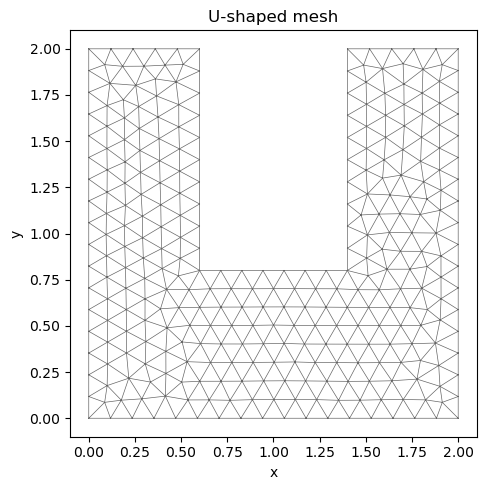

In [2]:
X_MAX    = 2.0
Y_MAX    = 2.0
NOTCH_X  = (0.6, 1.4)
NOTCH_Y  = 0.8
MESH_SIZE = 0.12

T_MAX    = 1.0   # total simulation time
KAPPA    = 0.05  # diffusion coefficient — small so dynamics are visible in [0, 1]

def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

u_polygon = [
    [0.0,        0.0     ],
    [X_MAX,      0.0     ],
    [X_MAX,      Y_MAX   ],
    [NOTCH_X[1], Y_MAX   ],
    [NOTCH_X[1], NOTCH_Y ],
    [NOTCH_X[0], NOTCH_Y ],
    [NOTCH_X[0], Y_MAX   ],
    [0.0,        Y_MAX   ],
]

with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(u_polygon, mesh_size=MESH_SIZE)
    mesh = geom.generate_mesh(dim=2, verbose=False)

verts = mesh.points[:, :2].copy()
faces = mesh.cells_dict["triangle"].astype(np.int64)

used        = np.unique(faces)
remap       = np.full(len(verts), -1, dtype=np.int64)
remap[used] = np.arange(len(used))
verts       = verts[used]
faces       = remap[faces]

print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")

fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal"); ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 3. Identify boundary nodes

Hot nodes  (u=1): 6
Cold nodes (u=0): 82
Interior nodes  : 223


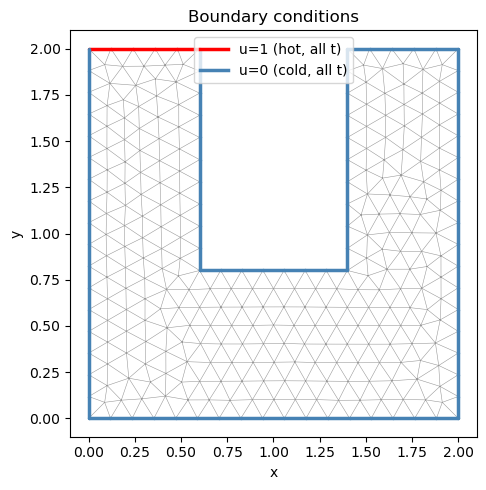

In [3]:
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

tol    = MESH_SIZE / 2
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol) & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")
print(f"Interior nodes  : {(~is_boundary).sum()}")

# ── Visualise ──────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot([verts[v0, 0], verts[v1, 0]], [verts[v0, 1], verts[v1, 1]],
                color=color, lw=2.5, solid_capstyle="round")
ax.legend(handles=[
    Line2D([0],[0], color="red",       lw=2.5, label="u=1 (hot, all t)"),
    Line2D([0],[0], color="steelblue", lw=2.5, label="u=0 (cold, all t)"),
])
ax.set_aspect("equal"); ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 4. Finite-difference reference solution (transient)

Solve $\partial_t u = \Delta u$ on a $100 \times 100$ regular grid with **implicit Euler** time stepping.

- Initial condition: $u(x,y,0) = 0$ everywhere  
- Spatial BCs: $u = 1$ on hot edge, $u = 0$ on cold edges (held for all $t$)  
- The resulting space-time interpolant `fd_solution(x)` accepts columns $(x, y, t)$.

In [ ]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import LinearNDInterpolator

# ── Spatial grid ──────────────────────────────────────────────────────────
N_FD = 100
xs_fd   = np.linspace(0, X_MAX, N_FD + 1)
ys_fd   = np.linspace(0, Y_MAX, N_FD + 1)
h_fd    = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
active   = in_u_shape(pts_flat).reshape(N_FD + 1, N_FD + 1)

node_id = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
node_id[active] = np.arange(active.sum())
n_dof   = active.sum()
ii, jj  = np.where(active)

def _is_bnd(i, j):
    if not active[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active[ni, nj]:
            return True
    return False

bnd   = np.array([_is_bnd(i, j) for i, j in zip(ii, jj)])
hot   = bnd & (YY_fd[ii, jj] >= Y_MAX - h_fd/2) & (XX_fd[ii, jj] <= NOTCH_X[0] + h_fd/2)
bc_val = np.where(hot, 1.0, 0.0)   # 1 on hot, 0 on cold

# ── Build stiffness matrix A = κ·Laplacian (5-point stencil) ─────────────
# For BC nodes: diagonal = -1.0 so that LHS[k,k] = 0-(-1) = +1 → u[k] = bc_val[k].
rows, cols, vals = [], [], []
for idx, (i, j) in enumerate(zip(ii, jj)):
    k = node_id[i, j]
    if bnd[idx]:
        rows.append(k); cols.append(k); vals.append(-1.0)
    else:
        rows.append(k); cols.append(k); vals.append(-KAPPA * 4.0 / h_fd**2)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id[i+di, j+dj]
            rows.append(k); cols.append(nk); vals.append(KAPPA * 1.0 / h_fd**2)

A_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n_dof, n_dof))

# ── Time stepping (implicit Euler): (M/dt - A) u^{n+1} = (M/dt) u^n + b_bc ─
N_TIME = 50
dt     = T_MAX / N_TIME
ts     = np.linspace(0, T_MAX, N_TIME + 1)

M_diag = np.ones(n_dof)
M_diag[bnd] = 0.0
M_mat  = sp.diags(M_diag / dt, format='csr')

LHS    = M_mat - A_mat
b_bc   = np.zeros(n_dof)
b_bc[bnd] = bc_val[bnd]

u_cur  = np.zeros(n_dof)

LHS_lu = spla.splu(LHS.tocsc())

U_all  = np.zeros((N_TIME + 1, n_dof))
U_all[0] = u_cur

for n in range(N_TIME):
    rhs       = (M_mat @ u_cur) + b_bc
    rhs[bnd]  = bc_val[bnd]
    u_cur     = LHS_lu.solve(rhs)
    U_all[n + 1] = u_cur

print(f"FD transient (κ={KAPPA}): {n_dof} DOFs × {N_TIME} time steps")
print(f"u range at t=T_MAX: [{U_all[-1].min():.4f}, {U_all[-1].max():.4f}]")

# ── Space-time interpolant ────────────────────────────────────────────────
xy_active = pts_flat[active.ravel()]
Xst, Yst, Tst, Ust = [], [], [], []
for n, t in enumerate(ts):
    Xst.append(xy_active[:, 0])
    Yst.append(xy_active[:, 1])
    Tst.append(np.full(n_dof, t))
    Ust.append(U_all[n])

Xst = np.concatenate(Xst)
Yst = np.concatenate(Yst)
Tst = np.concatenate(Tst)
Ust = np.concatenate(Ust)

fd_interp_st = LinearNDInterpolator(
    np.column_stack([Xst, Yst, Tst]), Ust, fill_value=np.nan
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """Space-time FD reference: (n_pts, 3) columns (x, y, t) -> (n_pts, 1)."""
    vals   = fd_interp_st(x[:, :3]).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals

print("Space-time interpolant ready.")


FD transient (κ=0.05): 7861 DOFs × 50 time steps
u range at t=T_MAX: [-0.0000, 1.0000]


## 5. Spatial domain & GNN state-integrator

`DomainMesh` is **purely spatial** — no `t_interval`.

`GNNMeshNetwork` is built with `use_state=True`: at each time step the encoder
receives **three** features per node — $(x_i,\; y_i,\; u^n_i)$ — turning the
GNN into a **learned step integrator** $u^n \mapsto u^{n+1}$.

The current nodal state `u_prev_nodes` is stored in `problem.params` and updated
after each solve; it is read inside `apply()` from `params_dict["fixed"]["u_prev_nodes"]`.

Hard constraints (hot / cold walls) are still enforced exactly via static condensation.


In [ ]:
# ── Purely spatial domain (no t_interval) ────────────────────────────────
domain = DomainMesh((verts, faces))

# Spatial BCs: hard-constrained in GNN
domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)

print(domain)

# ── State-integrator GNN ─────────────────────────────────────────────────
# use_state=True: encoder receives [x_i, y_i, u^n_i] per node.
# The network learns the map  u^n → u^{n+1}  constrained by the weak form.
net = GNNMeshNetwork(
    domain,
    hidden_dim=64,
    poly_order=10,
    message_steps=4,
    n_outputs=1,
    hard_constraints=True,
    use_state=True,
)
print(net)


DomainMesh(2D, n_nodes=311, n_conditions=2)
GNNMeshNetwork(n_nodes=311, n_faces=532, hidden_dim=64, poly_order=10, message_steps=4, n_outputs=1, hard_constraints=True)


## 6. PDE problem — weak form (spatial, MoL)

The implicit-Euler weak form residual at step $n+1$:

$$\int_\Omega \phi\,\frac{u^{n+1} - u^n}{\Delta t}\,d\Omega
+ \int_\Omega \nabla u^{n+1}\cdot\nabla\phi\,d\Omega = 0$$

`problem.params` carries **two** state arrays updated each step:

| key | shape | used by |
|-----|-------|---------|
| `"u_prev"` | `(n_cub,)` | `volume_fn` — $u^n$ at cubature pts for the residual |
| `"u_prev_nodes"` | `(n_nodes,)` | `GNNMeshNetwork.apply()` — $u^n$ as encoder input features |

Both are initialised to zero (IC $u=0$).


In [ ]:
def volume_fn(x, y, params, phi, grad_phi, derivative=None):
    """Implicit-Euler MoL weak form of (u^{n+1} - u^n)/dt - κ Δu^{n+1} = 0.

    x:        (n_pts, 2) — spatial columns (x, y)
    y:        (n_pts, 1) — current solution u^{n+1}
    phi:      (n_pts,)
    grad_phi: (n_pts, 2)
    params["fixed"]["u_prev"]:       (n_pts,) — u^n at cubature points
    params["fixed"]["u_prev_nodes"]: (n_nodes,) — u^n at mesh nodes (for GNN state)
    params["fixed"]["dt"]:           scalar
    params["fixed"]["kappa"]:        scalar — diffusion coefficient
    """
    u_prev = params["fixed"]["u_prev"]
    dt     = params["fixed"]["dt"]
    kappa  = params["fixed"]["kappa"]

    du_dx = derivative(y, x, 0, (0,))
    du_dy = derivative(y, x, 0, (1,))
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)

    return phi * (y[:, 0] - u_prev) / dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

# ── Number of time steps ────────────────────────────────────────────────
N_TIME = 20
dt     = T_MAX / N_TIME

problem = ProblemWeak(
    domain         = domain,
    volume_fn      = volume_fn,
    params         = {
        "u_prev":       None,         # cubature-point u^n   (initialized below)
        "u_prev_nodes": None,         # mesh-node u^n        (initialized below)
        "dt":           float(dt),
        "t_cur":        float(dt),
        "kappa":        float(KAPPA), # diffusion coefficient
    },
    input_names    = ["x", "y"],
    output_names   = ["u"],
    n_time_steps   = N_TIME,         # triggers BPTT rollout mode in Trainer
    cubature_order = 4,
    solution       = lambda x, p: fd_solution(
        np.column_stack([x, np.full(len(x), p["fixed"]["t_cur"])])
    ),
)

# Cubature points shape (n_cub, 2) and mesh nodes shape (n_nodes, 2)
cub_pts_np  = problem.cubature_data["pts"].reshape(-1, 2)
cub_pts_jax = jnp.array(cub_pts_np, dtype=jnp.float32)
n_cub       = len(cub_pts_np)
n_nodes     = len(verts)
mesh_jax    = jnp.array(verts, dtype=jnp.float32)

# IC: u = 0; must be real arrays so network.apply never sees None
problem.params["u_prev"]       = np.zeros(n_cub,   dtype=np.float32)
problem.params["u_prev_nodes"] = np.zeros(n_nodes, dtype=np.float32)

problem.show_problem()
print(f"\nκ = {KAPPA}  |  Cubature: {n_cub} pts  |  Mesh nodes: {n_nodes}  |  dt = {dt:.4f}  |  N_TIME = {N_TIME}")


<IPython.core.display.Math object>


κ = 0.05  |  Cubature: 3192 pts  |  Mesh nodes: 311  |  dt = 0.0500  |  N_TIME = 20


## 7. BPTT rollout training

Because the GNN weights are **shared** across all time steps, the natural training
objective is the **total loss over the full rollout**, not N independent per-step losses:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{n=0}^{N-1}
  \left\|\,\mathbf{R}\!\left(u_\theta^{n+1},\,u^n\right)\right\|^2$$

where $\mathbf{R}$ is the Galerkin weak-form residual vector and the state chain
$u^0 \!\to\! u^1 \!\to\! \cdots \!\to\! u^N$ is unrolled inside a single
`jax.lax.scan`.  Gradients flow back through the **entire trajectory** (BPTT).

This is computed in one `trainer.train()` call; no per-step re-compilation is needed.


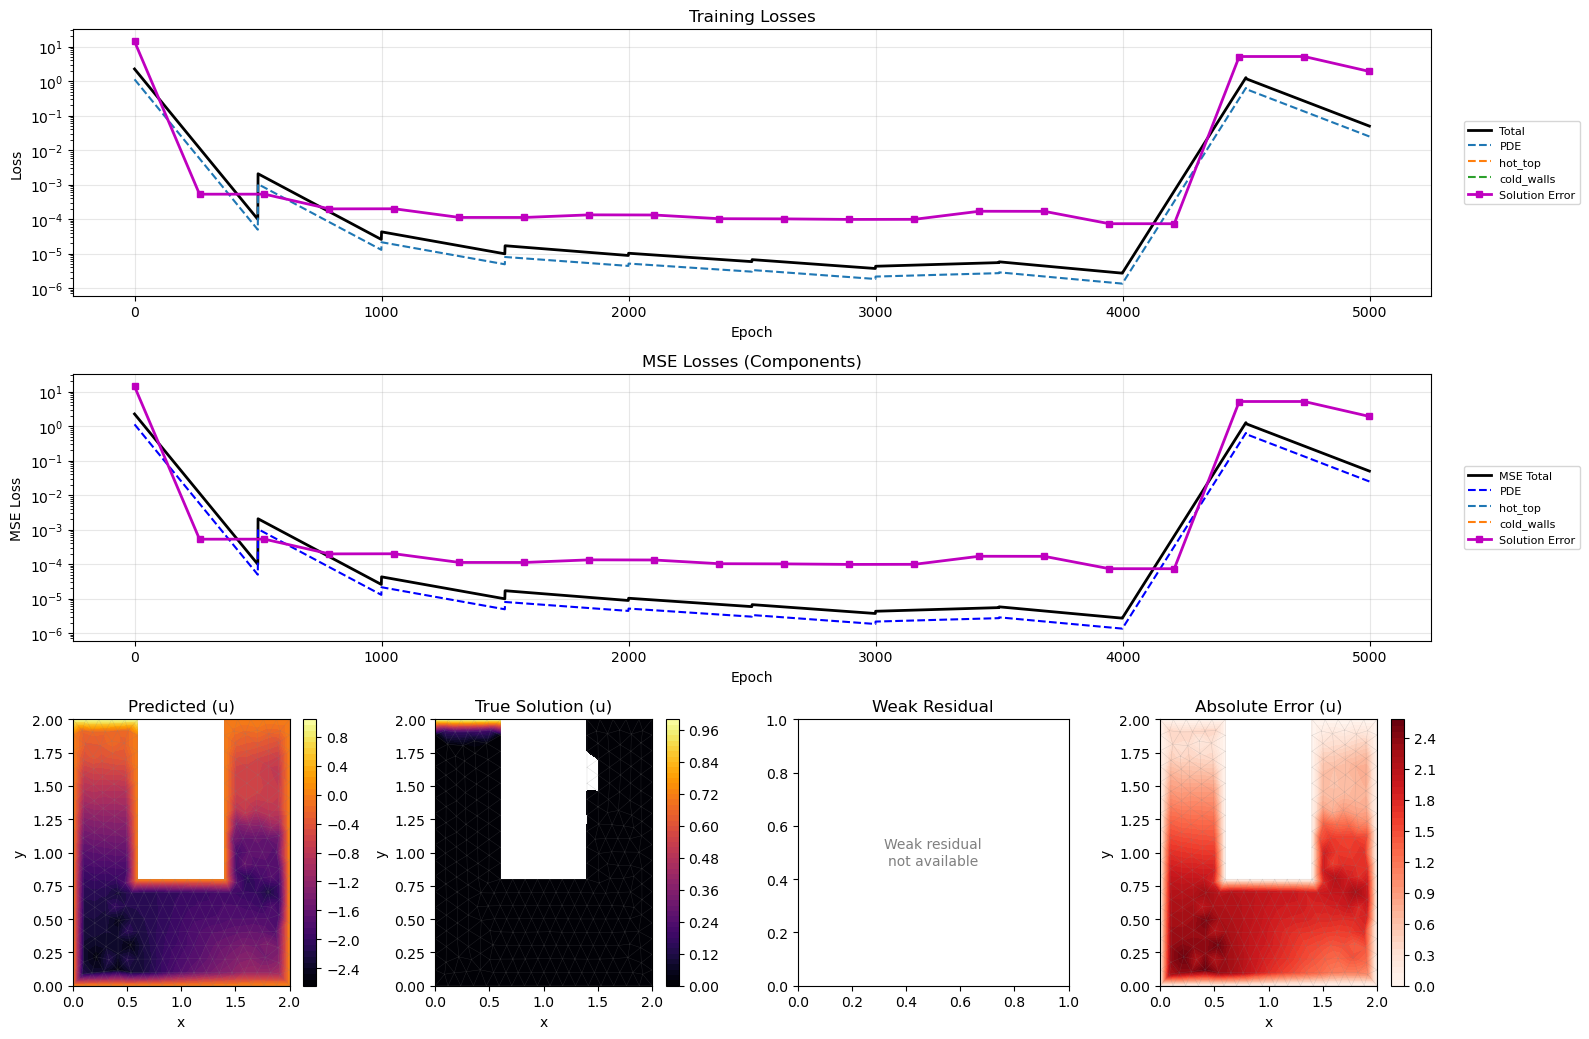

Stage 1/20 | Epoch 0/10000 | Loss: 2.26e+00 | MSE Loss: 2.26e+00 | PDE: 1.13e+00 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 0.0s | Error: 1.42e+01
Stage 1/20 | Epoch 500/10000 | Loss: 9.91e-05 | MSE Loss: 9.91e-05 | PDE: 4.95e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 37.8s | Error: 5.29e-04
Stage 2/20 | Epoch 500/10000 | Loss: 2.07e-03 | MSE Loss: 2.07e-03 | PDE: 1.03e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 0.0s | Error: 5.30e-04
Stage 2/20 | Epoch 1000/10000 | Loss: 2.58e-05 | MSE Loss: 2.58e-05 | PDE: 1.29e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 39.0s | Error: 1.98e-04
Stage 3/20 | Epoch 1000/10000 | Loss: 4.28e-05 | MSE Loss: 4.28e-05 | PDE: 2.14e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 0.0s | Error: 2.00e-04
Stage 3/20 | Epoch 1500/10000 | Loss: 9.87e-06 | MSE Loss: 9.87e-06 | PDE: 4.91e-06 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 39.1s | Error: 1.12e-04
Stage 4/20 | Epoch

In [ ]:
import time

ts = np.linspace(0.0, T_MAX, N_TIME + 1)    # [t_0, t_1, ..., t_N]

trainer = Trainer(problem, net)
trainer.compile(
    learning_rate        = 1e-3,
    epochs_by_time_step  = 500,
    print_each           = 500,
    show_plots           = True,
    grad_clip            = 1.0,   # clip global gradient norm — prevents BPTT explosion
)
trainer.train()